# How well does the Robertson Soil Behavior Type based on CPTs describe our Flemish peat samples?

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/DOV-Vlaanderen/pydov/master?filepath=docs%2Fworkshop%2Fpeat-samples-cpt-robertson.ipynb)

A practical example to query the DOV database using pydov to validate the Robertson Soil Behavior Type against observed data using samples, observations, boreholes and CPT measurements.

First, we retrieve all observations where a high content (at least 50%) of organic matter was measured. We also retrieve the depth below ground surface. Subsequently, we retrieve the borehole data via the corresponding sample, specifically the start level in mTAW. This allows us to determine the absolute depth (mTAW) of the sample.

Next, we perform a geographical search to find CPT measurements that are located near (within 5 meters) these peat samples. This allows us to efficiently retrieve the nearest CPT measurement for each of the samples. We also recalculate the CPT data to absolute elevation values in meter TAW, so that we can retain only the portion that corresponds planimetrically and altimetrically with the peat sample for further calculations.

Subsequently, the Robertson Soil Behavior Type analysis is performed for each sample (observation) based on the available CPT measurement data. Finally, the results are displayed in charts.

### Imports

First we import the required classes and libraries:

In [1]:
from pydov.search.observatie import ObservatieSearch
from pydov.search.monster import MonsterSearch
from pydov.search.sondering import SonderingSearch
from pydov.search.boring import BoringSearch

from pydov.types.observatie import Observatie
from pydov.types.sondering import Sondering

from pydov.search.fields import GeometryReturnField

from pydov.util.location import WithinDistance, GeopandasFilter
from pydov.util.query import Join

from owslib.fes2 import PropertyIsEqualTo

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

### Search objects

Next we create a search object for each dataset we need. These search objects can then be used to query each of the datasets.

In [2]:
observatie_search = ObservatieSearch()
monster_search = MonsterSearch()
sondering_search = SonderingSearch()
boring_search = BoringSearch()

We don't need all fields from all datasets: here we define which fields we want to retrieve for each dataset.

For the observations and CPT measurements we need the geometry in addition to the standard fields, to be able to perform the spatial join later.

We retrieve the CPT measurements in two phases: first only the permanent key and the geometry (needed for the spatial join), and only later the complete CPT data.

### Retrieve data

#### Peat observations

For the observations we also need the geometry in addition to the standard fields, which we add here:

In [3]:
observatie_fields = Observatie.get_field_names()
observatie_fields.extend([GeometryReturnField(f.name, 31370) for f in observatie_search.get_fields(type='geometry').values()])

observatie_fields

['pkey_observatie',
 'pkey_parent',
 'fenomeentijd',
 'diepte_van_m',
 'diepte_tot_m',
 'parametergroep',
 'parameter',
 'detectieconditie',
 'resultaat',
 'eenheid',
 'methode',
 'uitvoerder',
 'herkomst',

Now we can start retrieving the required data. First we retrieve the observations for the parameter 'Gehalte Organische stoffen' (Organic matter content). The result is a percentage and we convert it to numbers (float), to retain only those with a percentage of at least 50 percent.

We also add a column with the `pkey_monster` to which the observations are linked. When observations are linked to objects other than samples, this column will remain empty.

In [4]:
df_observaties = observatie_search.search(
    query= PropertyIsEqualTo('parameter', 'Gehalte Organische stoffen (Gehalte Organische stoffen)'),
    return_fields=observatie_fields
)
df_observaties['resultaat'] = df_observaties['resultaat'].astype(float)
df_observaties = df_observaties[df_observaties['resultaat'] >= 50]
df_observaties['pkey_monster'] =  df_observaties['pkey_parent'].apply(lambda x: x if 'monster' in x else np.nan)

df_observaties

[000/002] ..


,pkey_observatie,pkey_parent,fenomeentijd,diepte_van_m,diepte_tot_m,parametergroep,parameter,detectieconditie,resultaat,eenheid,methode,uitvoerder,herkomst,geom,pkey_monster
59,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2023-06-26,5.75,5.97,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,88.1,%,Chemische reactie met waterstofperoxide,NaN,LABO,POINT (150277.4 211260.94),https://www.dov.vlaanderen.be/data/monster/202...
90,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2023-10-04,7.50,7.90,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,62.6,%,Chemische reactie met waterstofperoxide,VO - Afdeling Geotechniek,LABO,POINT (143476.04 161514.62),https://www.dov.vlaanderen.be/data/monster/202...
99,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2023-10-04,6.70,7.00,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,60.7,%,Chemische reactie met waterstofperoxide,VO - Afdeling Geotechniek,LABO,POINT (143476.04 161514.62),https://www.dov.vlaanderen.be/data/monster/202...
102,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2017-04-05,7.50,8.00,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,75.8,%,Chemische reactie met waterstofperoxide,GMA,LABO,POINT (148857.03 212851.95),https://www.dov.vlaanderen.be/data/monster/201...
103,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2017-04-05,8.10,8.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,83.8,%,Chemische reactie met waterstofperoxide,GMA,LABO,POINT (148857.03 212851.95),https://www.dov.vlaanderen.be/data/monster/201...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13429,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2002-12-02,7.00,7.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,70.8,%,Chemische reactie met waterstofperoxide,VO - Afdeling Geotechniek,LABO,POINT (116790.49 189146.29),https://www.dov.vlaanderen.be/data/monster/201...
13542,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,1967-03-21,3.00,3.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,59.8,%,Chemische reactie met waterstofperoxide,Rijksinstituut voor Grondmechanica,LABO,POINT (153802 176597),https://www.dov.vlaanderen.be/data/monster/201...
13589,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2006-07-06,8.50,8.96,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,62.0,%,Chemische reactie met waterstofperoxide,Katholieke Universiteit Leuven (KUL),LABO,POINT (141229.95 225203.22),https://www.dov.vlaanderen.be/data/monster/201...
13751,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2007-04-17,4.50,4.98,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,54.8,%,Chemische reactie met waterstofperoxide,VO - Afdeling Geotechniek,LABO,POINT (119536.32 189184.38),https://www.dov.vlaanderen.be/data/monster/201...


We already have the (relative) depth available for these observations, but to convert this to absolute elevations we also need the start level (ground surface). This can be found via the sample and the borehole.

First we retrieve the samples to which these observations are linked and add a column with the `pkey_boring`. For samples linked to multiple boreholes, the first one is retained; for samples linked to other objects, this column remains empty.

In [5]:
df_monsters = monster_search.search(
    query=Join(df_observaties, on='pkey_monster'),
    return_fields=['pkey_monster', 'pkey_parents']
)
df_monsters['pkey_boring'] =  df_monsters['pkey_parents'].apply(lambda x: [i for i in x if 'boring' in i][0])
df_monsters

[000/001] .


,pkey_monster,pkey_parents,pkey_boring
0,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2001...
1,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2000...
2,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2001...
3,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2001...
4,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2001...
...,...,...,...
301,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2005...
302,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2008...
303,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2008...
304,https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2008...


Based on this link to the boreholes, we can finally retrieve the start level of the borehole:

In [6]:
df_boringen = boring_search.search(
    query=Join(df_monsters, on='pkey_boring'),
    return_fields=['pkey_boring', 'start_boring_mtaw']
)
df_boringen

[000/001] .


,pkey_boring,start_boring_mtaw
0,https://www.dov.vlaanderen.be/data/boring/1998...,6.58
1,https://www.dov.vlaanderen.be/data/boring/1998...,2.48
2,https://www.dov.vlaanderen.be/data/boring/1998...,4.54
3,https://www.dov.vlaanderen.be/data/boring/1999...,0.55
4,https://www.dov.vlaanderen.be/data/boring/2002...,6.89
...,...,...
256,https://www.dov.vlaanderen.be/data/boring/2013...,8.01
257,https://www.dov.vlaanderen.be/data/boring/2013...,6.00
258,https://www.dov.vlaanderen.be/data/boring/2013...,6.24
259,https://www.dov.vlaanderen.be/data/boring/2013...,2.09


Subsequently, we can merge all results back into a single dataframe using `pd.merge()`. First we merge the samples and the boreholes based on the `pkey_boring`, and then this result with the observations based on the `pkey_monster`:

In [7]:
df_monsters = pd.merge(df_monsters, df_boringen, 'outer', 'pkey_boring')
df_observaties = pd.merge(df_observaties, df_monsters, 'outer', 'pkey_monster')

df_observaties

,pkey_observatie,pkey_parent,fenomeentijd,diepte_van_m,diepte_tot_m,parametergroep,parameter,detectieconditie,resultaat,eenheid,methode,uitvoerder,herkomst,geom,pkey_monster,pkey_parents,pkey_boring,start_boring_mtaw
0,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/196...,1967-03-20,4.2,4.28,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,59.3,%,Chemische reactie met waterstofperoxide,Rijksinstituut voor Grondmechanica,LABO,POINT (153931 176643),https://www.dov.vlaanderen.be/data/monster/196...,(https://www.dov.vlaanderen.be/data/boring/196...,https://www.dov.vlaanderen.be/data/boring/1967...,17.83
1,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2006-08-03,11.0,11.47,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,92.2,%,Chemische reactie met waterstofperoxide,MVG - Afdeling Geotechniek,LABO,POINT (149350 196921),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2006...,8.24
2,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,1967-03-17,6.5,6.75,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,71.4,%,Chemische reactie met waterstofperoxide,Rijksinstituut voor Grondmechanica,LABO,POINT (154018 176662),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/196...,https://www.dov.vlaanderen.be/data/boring/1967...,18.47
3,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,1967-03-20,7.0,7.28,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,59.3,%,Chemische reactie met waterstofperoxide,Rijksinstituut voor Grondmechanica,LABO,POINT (153931 176643),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/196...,https://www.dov.vlaanderen.be/data/boring/1967...,17.83
4,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,1967-03-21,3.0,3.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,59.8,%,Chemische reactie met waterstofperoxide,Rijksinstituut voor Grondmechanica,LABO,POINT (153802 176597),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/196...,https://www.dov.vlaanderen.be/data/boring/1967...,17.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-18,8.0,8.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,76.2,%,Chemische reactie met waterstofperoxide,VO - Afdeling Geotechniek,LABO,POINT (140180.82 220020.08),https://www.dov.vlaanderen.be/data/monster/202...,(https://www.dov.vlaanderen.be/data/boring/202...,https://www.dov.vlaanderen.be/data/boring/2025...,6.27
302,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-20,7.5,7.90,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,97.8,%,Chemische reactie met waterstofperoxide,VO - Afdeling Geotechniek,LABO,POINT (140027.49 220118.96),https://www.dov.vlaanderen.be/data/monster/202...,(https://www.dov.vlaanderen.be/data/boring/202...,https://www.dov.vlaanderen.be/data/boring/2025...,6.38
303,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-21,9.5,10.00,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,67.4,%,Chemische reactie met waterstofperoxide,VO - Afdeling Geotechniek,LABO,POINT (139978.91 219818.45),https://www.dov.vlaanderen.be/data/monster/202...,(https://www.dov.vlaanderen.be/data/boring/202...,https://www.dov.vlaanderen.be/data/boring/2025...,7.26
304,htt

From this we create a GeoPandas GeoDataFrame, to be able to use in a pydov search query and later to use in the spatial join with the CPT measurements.

In [8]:
geo_df_observaties = gpd.GeoDataFrame(df_observaties, geometry='geom', crs='EPSG:31370')
geo_df_observaties.explore()

#### Nearby CPT measurements

Initially we want to build a dataframe of all nearby CPT measurements and their location, but without the complete CPT data yet. So first we only retrieve the permanent URL and the location:

In [9]:
sondering_fields_base = [
    'pkey_sondering',
]

sondering_fields_geom = [GeometryReturnField(f.name, 31370) for f in observatie_search.get_fields(type='geometry').values()]

sondering_fields_base.extend(sondering_fields_geom)

sondering_fields_base

['pkey_sondering', <pydov.search.fields.GeometryReturnField at 0x7fd823e7c050>]

Now that we have all peat samples available, we can search for all nearby CPT measurements. This can be done very easily by using the `GeopandasFilter` in pydov: with the following command we can find all CPT measurements that are located 5 meters or less from one of the previously found peat samples:

In [10]:
df_sonderingen_base = sondering_search.search(
    location=GeopandasFilter(geo_df_observaties, WithinDistance, {'distance': 5}),
    query=PropertyIsEqualTo('sondeermethode', 'continu elektrisch'),
    return_fields=sondering_fields_base
)
df_sonderingen_base

[000/001] .


,pkey_sondering,geom
0,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (141356.2 218562.1)
1,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (149606.6 213102.4)
2,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (149440.5 212336.7)
3,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (149579.8 212801.4)
4,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (149826.6 213310.4)
...,...,...
173,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (68564.5 223202.2)
174,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (122144.8 188881.2)
175,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (46343.3 211391.8)
176,https://www.dov.vlaanderen.be/data/sondering/2...,POINT (46012.1 211344)


We also create a GeoDataFrame from this:

In [11]:
geo_df_sonderingen_base = gpd.GeoDataFrame(df_sonderingen_base, geometry='geom', crs='EPSG:31370')
geo_df_sonderingen_base.explore()

Now we can join the two GeoDataFrames based on their location: this way we find for each observation which CPT measurement(s) are nearby, as well as their mutual distance:

In [12]:
df_joined = gpd.sjoin_nearest(geo_df_observaties, geo_df_sonderingen_base, max_distance=5, distance_col='dist')
df_joined

,pkey_observatie,pkey_parent,fenomeentijd,diepte_van_m,diepte_tot_m,parametergroep,parameter,detectieconditie,resultaat,eenheid,...,uitvoerder,herkomst,geom,pkey_monster,pkey_parents,pkey_boring,start_boring_mtaw,index_right,pkey_sondering,dist
1,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2006-08-03,11.0,11.47,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,92.2,%,...,MVG - Afdeling Geotechniek,LABO,POINT (149350 196921),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2006...,8.24,41,https://www.dov.vlaanderen.be/data/sondering/2...,0.322025
10,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2006-07-06,8.5,8.96,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,62.0,%,...,Katholieke Universiteit Leuven (KUL),LABO,POINT (141229.95 225203.22),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2006...,7.81,28,https://www.dov.vlaanderen.be/data/sondering/2...,3.019884
11,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2007-01-29,7.0,7.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,79.4,%,...,Katholieke Universiteit Leuven (KUL),LABO,POINT (140836.3 225113.28),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2007...,7.10,66,https://www.dov.vlaanderen.be/data/sondering/2...,1.801139
12,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2007-04-17,4.5,4.98,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,54.8,%,...,VO - Afdeling Geotechniek,LABO,POINT (119536.32 189184.38),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2007...,4.07,26,https://www.dov.vlaanderen.be/data/sondering/2...,2.993125
14,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2007-02-28,8.0,8.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,87.6,%,...,VO - Afdeling Geotechniek,LABO,POINT (152353 213884.55),https://www.dov.vlaanderen.be/data/monster/201...,(https://www.dov.vlaanderen.be/data/boring/200...,https://www.dov.vlaanderen.be/data/boring/2007...,7.66,25,https://www.dov.vlaanderen.be/data/sondering/2...,2.540709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-18,8.0,8.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,76.2,%,...,VO - Afdeling Geotechniek,LABO,POINT (140180.82 220020.08),https://www.dov.vlaanderen.be/data/monster/202...,(https://www.dov.vlaanderen.be/data/boring/202...,https://www.dov.vlaanderen.be/data/boring/2025...,6.27,138,https://www.dov.vlaanderen.be/data/sondering/2...,0.930054
302,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-20,7.5,7.90,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,97.8,%,...,VO - Afdeling Geotechniek,LABO,POINT (140027.49 220118.96),https://www.dov.vlaanderen.be/data/monster/202...,(https://www.dov.vlaanderen.be/data/boring/202...,https://www.dov.vlaanderen.be/data/boring/2025...,6.38,140,https://www.dov.vlaanderen.be/data/sondering/2...,4.396931
303,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-21,9.5,10.00,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,67.4,%,...,VO - Afdeling Geotechniek,L

Now we only need the CPT data itself: this can be requested based on the previously found CPT measurements, but now with the complete list of fields as return_fields:

In [13]:
sondering_fields = Sondering.get_field_names()
sondering_fields.extend(sondering_fields_geom)

sondering_fields

['pkey_sondering',
 'sondeernummer',
 'x',
 'y',
 'mv_mtaw',
 'start_sondering_mtaw',
 'diepte_sondering_van',
 'diepte_sondering_tot',
 'datum_aanvang',
 'uitvoerder',
 'sondeermethode',
 'apparaat',
 'datum_gw_meting',
 'diepte_gw_m',
 'lengte',
 'diepte',
 'qc',
 'Qt',
 'fs',
 'u',
 'i',

In [14]:
df_sonderingen = sondering_search.search(
    query=Join(df_sonderingen_base, 'pkey_sondering'),
    return_fields=sondering_fields
)
df_sonderingen

[000/001] .
[000/178] cccccccccccccccccccccccccccccccccccccccccccccccccc
[050/178] cccccccccccccccccccccccccccccccccccccccccccccccccc
[100/178] cccccccccccccccccccccccccccccccccccccccccccccccccc
[150/178] cccccccccccccccccccccccccccc


,pkey_sondering,sondeernummer,x,y,mv_mtaw,start_sondering_mtaw,diepte_sondering_van,diepte_sondering_tot,datum_aanvang,uitvoerder,...,datum_gw_meting,diepte_gw_m,lengte,diepte,qc,Qt,fs,u,i,geom
0,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/153-SZS126,141356.2,218562.1,NaN,6.75,1.2,32.15,2002-09-06,MVG - Afdeling Geotechniek,...,2002-09-06 00:00:00,1.15,1.25,1.25,9.96,NaN,110.0,NaN,-3.1,POINT (141356.2 218562.1)
1,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/153-SZS126,141356.2,218562.1,NaN,6.75,1.2,32.15,2002-09-06,MVG - Afdeling Geotechniek,...,2002-09-06 00:00:00,1.15,1.30,1.30,10.50,NaN,120.0,NaN,-3.1,POINT (141356.2 218562.1)
2,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/153-SZS126,141356.2,218562.1,NaN,6.75,1.2,32.15,2002-09-06,MVG - Afdeling Geotechniek,...,2002-09-06 00:00:00,1.15,1.35,1.35,17.02,NaN,140.0,NaN,-3.1,POINT (141356.2 218562.1)
3,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/153-SZS126,141356.2,218562.1,NaN,6.75,1.2,32.15,2002-09-06,MVG - Afdeling Geotechniek,...,2002-09-06 00:00:00,1.15,1.40,1.40,16.74,NaN,150.0,NaN,-3.1,POINT (141356.2 218562.1)
4,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/153-SZS126,141356.2,218562.1,NaN,6.75,1.2,32.15,2002-09-06,MVG - Afdeling Geotechniek,...,2002-09-06 00:00:00,1.15,1.45,1.45,16.13,NaN,160.0,NaN,-3.1,POINT (141356.2 218562.1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153411,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/182-S4,150522.5,221639.5,NaN,6.70,1.4,12.35,2002-02-27,MVG - Afdeling Geotechniek,...,2002-02-27 15:00:00,5.10,12.15,12.15,30.65,NaN,260.0,NaN,0.1,POINT (150522.5 221639.5)
153412,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/182-S4,150522.5,221639.5,NaN,6.70,1.4,12.35,2002-02-27,MVG - Afdeling Geotechniek,...,2002-02-27 15:00:00,5.10,12.20,12.20,27.91,NaN,250.0,NaN,0.1,POINT (150522.5 221639.5)
153413,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/182-S4,150522.5,221639.5,NaN,6.70,1.4,12.35,2002-02-27,MVG - Afdeling Geotechniek,...,2002-02-27 15:00:00,5.10,12.25,12.25,28.06,NaN,250.0,NaN,0.1,POINT (150522.5 221639.5)
153414,https://www.dov.vlaanderen.be/data/sondering/2...,GEO-01/182-S4,150522.5,221639.5,NaN,6.70,1.4,12.35,2002-02-27,MVG - Afdeling Geotechniek,...,2002-02-27 15:00:00,5.10,12.30,12.30,27.85,NaN,260.0,NaN,0.1,POINT (150522.5 221639.5)


### Data analysis

Now that we have all the data, we can start our analysis. First we create an empty dataframe with the required columns to later save the results in:

In [15]:
new_columns = [
    'pkey_observatie',
    "qc_avg",
    "qc_med",
    "qc_var",
    "fs_avg",
    "fs_med",
    "fs_var",
    "rf_avg",
    "rf_med",
    "rf_var",
    "Qtn_avg",
    "Qtn_med",
    "Qtn_var",
    "F_avg",
    "F_med",
    "F_var",
    "IC_avg",
    "IC_med",
    "IC_var",
]  # create the variables that you want to store
sonddata_df = pd.DataFrame(
   columns=new_columns
)  # make a dataframe with the same shape as gdf but with above specified columns

And we perform the actual analysis. For each observation (peat sample), the nearest CPT measurement is searched and its data is loaded. After converting both the observation and the CPT data to meter TAW, the Robertson Soil Behavior Type parameters can be calculated. These are added to the result dataframe.

In [16]:
for observation in set(df_joined['pkey_observatie']):
    nearest_sondering = df_joined[df_joined['pkey_observatie'] == observation].sort_values(by='dist', ascending=False).iloc[0]['pkey_sondering']

    sondering_data = df_sonderingen[
        (df_sonderingen['pkey_sondering'] == nearest_sondering)
        & (df_sonderingen['fs'] > 0)
        & (df_sonderingen['qc'] > 0)
    ].copy()

    observatie_data = df_joined[df_joined['pkey_observatie'] == observation]

    if sondering_data.size == 0:
        continue

    sondering_data["rf"] = sondering_data["fs"] / sondering_data["qc"] / 10  # calculate rf

    # convert depths to relative levels
    sondering_data["mtaw"] = (
        sondering_data["start_sondering_mtaw"] - sondering_data["diepte"]
    )
    sondering_data["mtaw"] = sondering_data["mtaw"].fillna(sondering_data["start_sondering_mtaw"] - sondering_data["lengte"])

    # for the moment there will be no correction with the lag index, this is hard to do automatically, could possibly be done by looking at max curvature or by looping through the indices and finding the first maxima
    sondering_data["unitw"] = 9.81 * (
        0.27 * np.log10(sondering_data["rf"]) + 0.36 * np.log10((sondering_data["qc"] / 0.1)) + 1.236
    )  # calculate unitw

    # if there is no groundwaterdata then take GW equal to start of the sounding
    sondering_data["diepte_gw_m"] = sondering_data["diepte_gw_m"].fillna(sondering_data["start_sondering_mtaw"])

    # if above the groundwater, give a value 0 for pwp
    sondering_data.loc[sondering_data['lengte'] < sondering_data['diepte_gw_m'], 'pwp'] = 0
    # if below GW, give value equal to hydrostatic pwp
    sondering_data.loc[sondering_data['lengte'] >= sondering_data['diepte_gw_m'], 'pwp'] = (sondering_data["lengte"] - sondering_data["diepte_gw_m"]) * 9.81

    sondering_data["stot"] = 0  # make a stot column
    sondering_data['stot'] = (sondering_data['lengte'] - sondering_data['lengte'].shift(1).fillna(0)) * sondering_data['unitw']
    sondering_data['stot'] = sondering_data['stot'].cumsum()

    sondering_data["seff"] = sondering_data["stot"] - sondering_data["pwp"]  # calculate effective stress
    if sondering_data["seff"].isna().any():  # check i used for detecting nan values
        print(f"NaN found for 'seff' in rows {sondering_data[sondering_data['seff'].isna()].index}")
        break

    sondering_data["Qtn"] = ((sondering_data["qc"] * 1000 - sondering_data["stot"]) / 100) * (
        100 / sondering_data["seff"]
    )  # calculate corrected Qtn
    sondering_data["F"] = sondering_data["fs"] * 100 / (sondering_data["qc"] * 1000 - sondering_data["stot"])
    # calculate corrected F-factor
    sondering_data["IC"] = (
        (3.47 - np.log10(sondering_data["Qtn"])) ** 2 + (np.log10(sondering_data["F"]) + 1.22) ** 2
    ) ** 0.5  # Ic for soil behaviour type

    sondering_data["peil"] = (
        sondering_data["start_sondering_mtaw"] - sondering_data["lengte"]
    )  # absolute level

    bovenpeil = (observatie_data['start_boring_mtaw'] - observatie_data["diepte_van_m"]).iloc[0]  # extract boundaries of sample
    onderpeil = (observatie_data['start_boring_mtaw'] - observatie_data["diepte_tot_m"]).iloc[0]  # extract boundaries of sample

    sondering_data_subset = sondering_data[
        (sondering_data["peil"] <= bovenpeil) & (sondering_data["peil"] >= onderpeil)
    ]  # define a subset with the CPT values at the depth of the sample
    if sondering_data_subset.size == 0:  # if this subset is empty just restart loop
        continue
    mean_values = sondering_data_subset.mean(numeric_only=True)  # find mean
    median_values = sondering_data_subset.median(numeric_only=True)  # find median

    if len(sondering_data_subset) > 1:
        variance_values = (
            sondering_data_subset.var(numeric_only=True)
        )  # find variance if there is more than one datapoint
    else:
        variance_values = pd.Series(
            [0 for _ in sondering_data_subset.columns], index=sondering_data_subset.columns
        )  # if this in not the case put a 0 for variance

    new_data = pd.DataFrame(index=observatie_data.index, data={
        'pkey_observatie': observatie_data['pkey_observatie'].iloc[0],
        "qc_avg": mean_values["qc"],
        "fs_avg": mean_values["fs"],
        "rf_avg": mean_values["rf"],
        "Qtn_avg": mean_values["Qtn"],
        "F_avg": mean_values["F"],
        "IC_avg": mean_values["IC"],
        "qc_med": median_values["qc"],
        "fs_med": median_values["fs"],
        "rf_med": median_values["rf"],
        "Qtn_med": median_values["Qtn"],
        "F_med": median_values["F"] ,
        "qc_var": variance_values["qc"],
        "fs_var": variance_values["fs"],
        "rf_var": variance_values["rf"],
        "Qtn_var": variance_values["Qtn"],
        "F_var": variance_values["F"],
        "IC_var": variance_values["IC"],
    })

    sonddata_df = pd.concat([sonddata_df, new_data], ignore_index=True)

sonddata_df


/tmp/ipykernel_69852/329157286.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sonddata_df = pd.concat([sonddata_df, new_data], ignore_index=True)
/home/roel/Work/DOV/pydov/Code/pydov/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/roel/Work/DOV/pydov/Code/pydov/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/roel/Work/DOV/pydov/Code/pydov/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)

,pkey_observatie,qc_avg,qc_med,qc_var,fs_avg,fs_med,fs_var,rf_avg,rf_med,rf_var,Qtn_avg,Qtn_med,Qtn_var,F_avg,F_med,F_var,IC_avg,IC_med,IC_var
0,https://www.dov.vlaanderen.be/data/observatie/...,0.630200,0.620,0.002412,49.240000,49.0,11.773333,7.821904,7.894737,0.070205,4.740368,4.645491,0.205764,9.744119,9.866772,0.185043,3.562928,NaN,0.001710
1,https://www.dov.vlaanderen.be/data/observatie/...,1.212000,1.240,0.012442,103.760000,104.0,312.190000,8.503695,8.474576,0.671222,8.551131,8.765523,0.970369,9.653296,9.672040,0.662625,3.363599,NaN,0.000734
2,https://www.dov.vlaanderen.be/data/observatie/...,1.631667,1.670,0.013657,138.833333,141.5,42.166667,8.523800,8.476587,0.095081,9.730427,9.984077,0.642491,9.516977,9.431645,0.174604,3.316316,NaN,0.001501
3,https://www.dov.vlaanderen.be/data/observatie/...,1.020000,1.070,0.014900,111.240000,118.0,186.690000,10.905240,10.882353,0.117365,10.090128,10.621029,2.482326,12.843006,12.893282,0.240293,3.395762,NaN,0.003559
4,https://www.dov.vlaanderen.be/data/observatie/...,0.889080,0.849,0.028728,70.640000,63.5,296.439184,8.116217,8.372675,3.840904,7.685592,7.196305,2.940919,9.358642,9.794007,5.273899,3.384799,NaN,0.017229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,https://www.dov.vlaanderen.be/data/observatie/...,1.056364,1.070,0.005745,84.545455,86.0,86.672727,7.991460,7.909091,0.241539,6.060677,6.180074,0.233525,9.421659,9.279148,0.320236,3.470083,NaN,0.000919
192,https://www.dov.vlaanderen.be/data/observatie/...,1.260000,1.220,0.039150,99.000000,101.0,68.500000,7.953141,8.362069,0.839800,19.887764,19.228392,9.879201,8.661825,9.146527,1.125909,3.061948,NaN,0.007006
193,https://www.dov.vlaanderen.be/data/observatie/...,0.830000,0.850,0.007775,66.666667,70.0,25.000000,8.062722,8.045977,0.193296,9.113621,9.487740,1.727365,9.800348,9.897149,0.522967,3.347741,NaN,0.004492
194,https://www.dov.vlaanderen.be/data/observatie/...,0.892222,0.880,0.002769,73.444444,76.0,139.277778,8.195528,8.351648,0.829784,6.439954,6.355233,0.323608,9.467302,9.621253,0.925751,3.450596,NaN,0.000276


The results are then merged with the source data of the observations, based on the `pkey_observatie`:

In [17]:
merged_df = pd.merge(geo_df_observaties, sonddata_df, on='pkey_observatie')  # join the two dataframes together
merged_df = merged_df.dropna(
    subset=["Qtn_avg"]
)  # drop all rows with nan values
merged_df

,pkey_observatie,pkey_parent,fenomeentijd,diepte_van_m,diepte_tot_m,parametergroep,parameter,detectieconditie,resultaat,eenheid,...,rf_var,Qtn_avg,Qtn_med,Qtn_var,F_avg,F_med,F_var,IC_avg,IC_med,IC_var
0,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2006-08-03,11.0,11.47,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,92.2,%,...,0.445840,9.501619,9.433575,0.428062,9.610620,9.513810,0.625950,3.326070,NaN,0.001339
1,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2006-07-06,8.5,8.96,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,62.0,%,...,0.495409,10.109567,9.796345,1.498985,9.975426,10.416742,0.750912,3.317791,NaN,0.003992
2,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2007-01-29,7.0,7.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,79.4,%,...,1.376713,13.505217,12.992110,4.110502,8.358371,8.389959,1.720787,3.171420,NaN,0.008375
3,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2007-04-17,4.5,4.98,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,54.8,%,...,0.237022,11.511098,11.103406,2.300224,10.365036,10.613481,0.421005,3.288280,NaN,0.002691
4,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/201...,2007-02-28,8.0,8.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,87.6,%,...,0.450051,8.659261,8.238914,1.503024,4.338650,4.028841,0.505988,3.141798,NaN,0.000813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-14,6.5,7.00,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,95.7,%,...,4.931109,23.646598,21.726537,26.986828,11.329137,11.034213,5.955055,3.091688,NaN,0.014351
192,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-20,7.5,7.90,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,97.8,%,...,0.220248,8.106500,8.026561,0.220557,11.754576,11.861887,0.334535,3.435978,NaN,0.000856
193,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-03-21,9.5,10.00,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,67.4,%,...,1.995651,7.533010,7.318299,0.667049,8.130456,7.378547,2.626026,3.353749,NaN,0.001325
194,https://www.dov.vlaanderen.be/data/observatie/...,https://www.dov.vlaanderen.be/data/monster/202...,2025-08-29,9.0,9.50,Onderkenning - proeven,Gehalte Organische stoffen (Gehalte Organische...,NaN,81.7,%,...,0.316637,5.595731,5.753455,0.606544,10.668221,10.502535,0.768665,3.532824,NaN,0.004671


Finally, we can display these results in a chart:

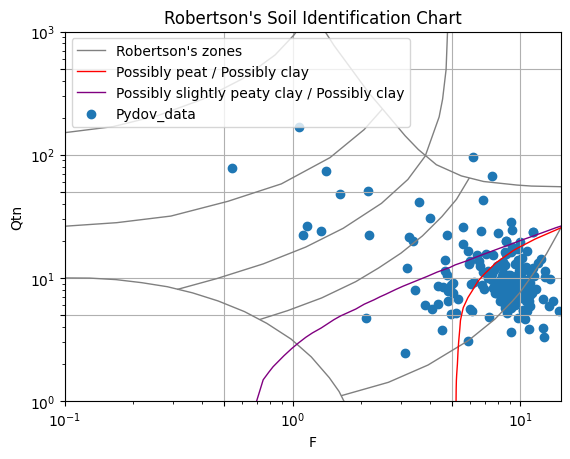

In [18]:
# define boundaries for Roberson's graph and plot them
X1 = np.array(
    [
        -3,
        -1,
        -0.890243902439026,
        -0.774390243902441,
        -0.66158536585366,
        -0.548780487804878,
        -0.439024390243903,
        -0.326219512195123,
        -0.210365853658537,
        -0.112804878048781,
        -0.00609756097560987,
        0.082317073170729,
        0.161585365853658,
        0.204268292682926,
        0.225609756097559,
        0.397940008672038,
        0.52244423350632,
        3,
    ]
)
Y1 = np.array(
    [
        1,
        1,
        0.998624484181568,
        0.98624484181568,
        0.961485557083906,
        0.92847317744154,
        0.878954607977991,
        0.812929848693259,
        0.726272352132049,
        0.631361760660247,
        0.50343878954608,
        0.359009628610727,
        0.189821182943603,
        0.0784044016506188,
        0,
        -0.476892499139314,
        -1,
        -1,
    ]
)
X2 = np.array(
    [
        -3,
        0.079181246,
        0.131097560975609,
        0.182926829268291,
        0.246951219512193,
        0.292682926829266,
        0.335365853658536,
        0.38109756097561,
        0.445121951219511,
        0.493902439024389,
        0.551829268292683,
        0.631097560975609,
        0.740853658536585,
        0.838414634146341,
        0.984756097560975,
        1.04878048780488,
        1.17609125905568,
        3,
    ]
)
Y2 = np.array(
    [
        4,
        4,
        3.03301237964236,
        2.88445667125172,
        2.72352132049518,
        2.6079779917469,
        2.50068775790921,
        2.40165061898212,
        2.26134800550206,
        2.15405777166437,
        2.04264099037139,
        1.91884456671252,
        1.82806052269601,
        1.78266850068776,
        1.75378266850069,
        1.7455295735901,
        1.74036268949424,
        1.73639650227664,
    ]
)
X3 = np.array(
    [
        -3,
        -2,
        -1.04575749056068,
        -0.522878745280338,
        -0.0457574905606751,
        0.216463414634144,
        0.420731707317072,
        0.594512195121951,
        0.771341463414634,
        0.887195121951219,
        0.963414634146341,
        0.996951219512195,
        1.04139268515823,
        1.11394335230684,
        1.20411998265592,
        1.252574989,
        1.30102999566398,
        1.47712125471966,
        1.61172330800734,
        3,
    ]
)
Y3 = np.array(
    [
        -0.107504662868674,
        -0.107504662868674,
        -0.099484807248056,
        -0.0784326862439331,
        -0.0182837690892966,
        0.045392022008251,
        0.15268225584594,
        0.292984869325996,
        0.491059147180191,
        0.664374140302613,
        0.808803301237964,
        0.878954607977991,
        0.994223003013752,
        1.19471939352921,
        1.49546397930239,
        1.6959604,
        1.8964567603333,
        2.89893871291058,
        4,
        4,
    ]
)

X4 = np.array(
    [
        -3,
        -2,
        -1,
        -0.522878745280338,
        -0.301029995663981,
        -0.140243902439025,
        -0.0213414634146342,
        0.128048780487803,
        0.277439024390242,
        0.378048780487804,
        0.47560975609756,
        0.570121951219511,
        0.655487804878049,
        0.71951219512195,
        0.774390243902439,
        0.845098040014257,
        0.954242509439325,
        1.07918124604762,
        1.21218760440396,
        3,
    ]
)
Y4 = np.array(
    [
        0.548714105446867,
        0.548714105446867,
        0.567812943589182,
        0.610254806127659,
        0.652696668666137,
        0.664374140302613,
        0.734525447042641,
        0.837689133425034,
        0.969738651994498,
        1.08115543328748,
        1.20082530949106,
        1.34112792297111,
        1.49793672627235,
        1.63823933975241,
        1.80742778541953,
        2.03205720116665,
        2.45647582655142,
        3.09310376462857,
        4,
        4,
    ]
)

X5 = np.array(
    [
        -3,
        -2,
        -1.39794000867204,
        -0.823908740944319,
        -0.503048780487805,
        -0.332317073170732,
        -0.128048780487805,
        0.0579268292682913,
        0.222560975609754,
        0.390243902439023,
        0.506097560975609,
        0.582317073170732,
        0.643292682926829,
        0.658536585365853,
        0.673780487804877,
        0.679878048780487,
        0.700578048780487,
        3,
    ]
)
Y5 = np.array(
    [
        0.793022628459515,
        0.793022628459515,
        0.803892063893693,
        0.84374666048568,
        0.907840440165061,
        0.994497936726272,
        1.11416781292985,
        1.25034387895461,
        1.40302613480055,
        1.60522696011004,
        1.79917469050894,
        1.98899587345254,
        2.30674002751032,
        2.45116918844567,
        2.69050894085282,
        2.98762035763411,
        4,
        4,
    ]
)

X6 = np.array(
    [
        -3,
        -2,
        -1.39794000867204,
        -1,
        -0.771341463414636,
        -0.533536585365855,
        -0.283536585365854,
        -0.0487804878048781,
        0.164634146341461,
        0.314024390243902,
        0.393292682926828,
        0.423780487804877,
        0.544068044350276,
        0.698970004336019,
        0.807589142389764,
        3,
    ]
)
Y6 = np.array(
    [
        1.39511433919444,
        1.39511433919444,
        1.4073041167125,
        1.41953232462173,
        1.4484181568088,
        1.50206327372765,
        1.62173314993122,
        1.76342799356294,
        1.97661623108666,
        2.20357634112792,
        2.36863823933975,
        2.45942228335626,
        2.81319179046214,
        3.42268066636517,
        4,
        4,
    ]
)

X7 = np.array(
    [
        -3,
        -2,
        -1.52287874528034,
        -1.15490195998574,
        -1,
        -0.786585365853661,
        -0.588414634146342,
        -0.39329268292683,
        -0.219512195121951,
        -0.076219512195122,
        0.00609756097560594,
        0.0304878048780472,
        0.113943352306837,
        0.204119982655925,
        0.34409740359441,
        3,
    ]
)
Y7 = np.array(
    [
        2.10124566205107,
        2.10124566205107,
        2.11851911705649,
        2.15306602706735,
        2.17881705639615,
        2.22833562585969,
        2.3191196698762,
        2.45116918844567,
        2.6162310866575,
        2.8101788170564,
        2.97111416781293,
        3.03301237964236,
        3.21538350990112,
        3.47448533498253,
        4,
        4,
    ]
)

Y8 = np.array(
    [
        1,
        1.236584507,
        1.467593452,
        1.641390069,
        2.00087167,
        2.561283296,
        3.04027751,
        3.864751926,
        4.513435735,
        5.329418952,
        5.737406993,
        6.934489818,
        7.871627474,
        9.405725877,
        10.71461614,
        13.26504071,
        14.33512247,
        16.67039577,
        17.48101531,
        20.73321573,
        25.76980375,
        30.8239924,
    ]
)
X8 = np.array(
    [
        5.218732546,
        5.224237832,
        5.235265833,
        5.251851499,
        5.290756014,
        5.324332041,
        5.358121147,
        5.420625748,
        5.45502595,
        5.559541963,
        5.61254852,
        5.885259102,
        6.145248773,
        6.512143221,
        6.934981111,
        7.811089495,
        8.281805716,
        9.300236388,
        9.731586954,
        11.63135731,
        15.24313395,
        19.81818615,
    ]
)

Y9 = np.array(
    [
        1,
        1.24570471,
        1.457672448,
        1.734757,
        2.022753999,
        2.244335431,
        2.546558574,
        2.887030331,
        3.29529913,
        4.377751156,
        5.390771626,
        5.982484067,
        7.152449831,
        7.972379175,
        9.518039505,
        10.38663667,
        11.63636757,
        12.44098606,
        13.1809551,
        14.21891386,
        15.08325454,
        16.11449903,
        16.95549455,
        19.15734093,
        20.67643722,
        22.67543126,
        25.76980375,
        31.22082999,
    ]
)
X9 = np.array(
    [
        2.359210475,
        2.381703987,
        2.412029295,
        2.450479487,
        2.481680486,
        2.521240988,
        2.572257547,
        2.660524333,
        2.751819986,
        3.00507027,
        3.314662302,
        3.499621817,
        3.91963219,
        4.195462425,
        4.867922672,
        5.240788561,
        5.866673096,
        6.2441507,
        6.626424983,
        7.192139126,
        7.700695838,
        8.334363447,
        8.93498453,
        10.23676764,
        11.22018726,
        12.69483156,
        15.00257488,
        19.66118419,
    ]
)

Y10 = np.array(
    [
        1,
        1.490163293,
        1.722664767,
        1.902319213,
        2.331621252,
        2.669482766,
        2.950129966,
        3.29529913,
        3.574741878,
        3.924187211,
        4.578962969,
        4.912810557,
        5.593309253,
        6.119288823,
        6.644642623,
        7.023246768,
        7.361639679,
        8.081269437,
        8.575422275,
        10.30942724,
        11.15336857,
        12.18152662,
        12.75222616,
        13.7914596,
        14.48171973,
        15.39332793,
        16.55068513,
        17.67101739,
        18.40892945,
        20.02936469,
        21.64511984,
        22.72845428,
        23.96333726,
        25.50421875,
        27.14418142,
        28.48824655,
        30.28155009,
    ]
)
X10 = np.array(
    [
        0.695855433,
        0.743646766,
        0.788045272,
        0.821991165,
        0.916285475,
        0.991683911,
        1.058117967,
        1.143377667,
        1.221904814,
        1.336468837,
        1.518324783,
        1.624314987,
        1.896625055,
        2.063542636,
        2.279566394,
        2.419670763,
        2.561432124,
        2.846248441,
        3.057806323,
        3.908489836,
        4.312064256,
        4.914335096,
        5.169445303,
        5.837057497,
        6.223493829,
        6.785502665,
        7.532065355,
        8.288357264,
        8.822649179,
        9.933738163,
        11.18475323,
        12.03638898,
        13.01858971,
        14.26925174,
        15.81417007,
        16.90919862,
        18.5825382,
    ]
)

plt.plot(
    10**X1, 10**Y1, color="grey", linestyle="-", linewidth=1, label="Robertson's zones"
)
plt.plot(10**X2, 10**Y2, color="grey", linestyle="-", linewidth=1)
plt.plot(10 ** X3[5:16], 10 ** Y3[5:16], color="grey", linestyle="-", linewidth=1)
plt.plot(10 ** X4[5:15], 10 ** Y4[5:15], color="grey", linestyle="-", linewidth=1)
plt.plot(10 ** X5[4:17], 10 ** Y5[4:17], color="grey", linestyle="-", linewidth=1)
plt.plot(10 ** X6[0:11], 10 ** Y6[0:11], color="grey", linestyle="-", linewidth=1)
plt.plot(10 ** X7[0:13], 10 ** Y7[0:13], color="grey", linestyle="-", linewidth=1)
plt.plot(
    X8,
    Y8,
    color="red",
    linestyle="-",
    linewidth=1,
    label="Possibly peat / Possibly clay",
)
# plt.plot(X9,Y9, color='black',linestyle='-', linewidth=1, label="Lengkeek & Brinkgreve zone 2B")
plt.plot(
    X10,
    Y10,
    color="purple",
    linestyle="-",
    linewidth=1,
    label="Possibly slightly peaty clay / Possibly clay",
)


# Customize the plot
plt.title("Robertson's Soil Identification Chart")
plt.xlabel("F")
plt.ylabel("Qtn")
plt.grid(True)
plt.xscale("log")
plt.yscale("log")

# Set custom x and y axis labels
x_labels = [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
y_labels = [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
plt.xticks(x_labels)
plt.yticks(y_labels)
plt.xlim([0.1, 15])
plt.ylim([1, 1000])

# Average values from your DataFrame (replace with your actual values)
avg_Qtn = merged_df["Qtn_avg"]
avg_F = merged_df["F_avg"]

# just plot the dots
plt.scatter(avg_F, avg_Qtn, label="Pydov_data")
plt.legend()